In [1]:
import scanpy as sc
import pandas as pd
# from scipy.io import mmread
import numpy as np
import scipy.sparse as sp
import os
import anndata as ad

# from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy.external as sce  # Harmony 在 sc.external
# from sklearn.decomposition import PCA
import harmonypy as hm
import warnings
warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)

ModuleNotFoundError: No module named 'harmonypy'

In [3]:
adata = sc.read_h5ad("./adata_05a_with_embeddings.h5ad")
adata

AnnData object with n_obs × n_vars = 49641 × 27187
    obs: 'prject', 'nUMI', 'nGene', 'cellID', 'Doublet_Score', 'Doublet_Class', 'log10GenesPerUMI', 'mitoRatio', 'riboRatio1', 'riboRatio2', 'riboRatio3', 'riboRatio4', 'riboRatio', 'RNA_snn_res.0', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'seurat_clusters', 'class1', 'sample', 'source', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1.2', 'RNA_snn_res.1.4', 'RNA_snn_res.1.6', 'RNA_snn_res.1.8', 'RNA_snn_res.2', 'cellType', 'dcellType', 'cell', 'patient', 'timing', 'category', 'response', 'sub.response', 'date', 'start', 'daysSinceStart', 'blast', 'age', 'sex', 'FAB', 'cellCount', 'monthsSinceStart', 'relapse', 'daysStartRelapse', 'monthsStartRelapse', 'azimuthNames', 'mut', 'p53.mut', 'n_counts', 'venetoclax', 'treat'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.varianc

In [ ]:

adata_ctrl = adata[adata.obs["patient"].isin(["HCBM1","HCBM2","HCBM3"])].copy()
adata_aml = adata[~adata.obs["patient"].isin(["HCBM1","HCBM2","HCBM3"])].copy()

In [ ]:
hierarchical_markers = {
    "CD4": {
        # "general": ["CD4", "IL7R", "MAL", "LEF1", "LTB", "LDHB", "TPT1", "TRAC", "TCF7", "TMSB10", "LEPROTL1","CD3D", "CD3E","CD3G", "CD27"],   # broad CD4 T cell markers
         "general": ["CD4", "IL7R", "MAL", "LTB"],   # broad CD4 T cell markers
        "subtypes": {
            "CD4 Memory T cells": ["CXCR3", "IL7R", "LTB"],
            "CD4 Naive T cells": ["LEF1","TCF7","SELL","CD44"], #Naive "IL7R", "LTB"
            "CD4 CTL T cells": ["GZMB","PRF1","GNLY","NKG7"],
            "CD4 Exhausted T cells": ["CTLA4","LAG3","TIGIT","HAVCR2","PDCD1"],
            "CD4 Th1 T cells": ["TBX21","STAT4","IFNG","IL12A"],
            "CD4 Th2 T cells": ["STAT6","GATA6","IL4"],
            "CD4 Th17 T cells": ["IL7RA","STAT3","RORC"],
            "CD4 Tfh T cells": ["BCL6","CXCR5"],
            "Treg": ["TGFB1","FOXP3","IL2RA","IKZF2"]
        }
    },
    "CD8": {
        # "general": ["CD8A","CD8B","NELL2", "CD3D", "CD3E", "S100B", "GZMH", "CD3G", "TRGC2", "CCL5"],
        "general": ["CD8A","CD8B", "CD3D" ],
        "subtypes": {
            "CD8 Naive T cells": ["NELL2","CD8B","CCR7","LEF1","SELL","IL7R"],
            "CD8 Effector Memory T cells": ["PRF1","FGFBP2","FCGR3A","KLRD1","NKG7","KLRG1","CX3CR1"],
            "CD8 Exhausted T cells": ["CTLA4","LAG3","TIGIT","PDCD1","TOX"],
            "CD8 CTL T cells": ["GZMB","PRF1","GNLY","NKG7","GZMA"],
            "MAIT": ["KLRB1","IL7R","SLC4A10","RORC"]
        }
    },
    # "B": {
    #     "general": ["FCRL1", "FCRL2", "CD22", "ARHGAP24", #Azimuth
    #                                                            "BANK1", "MS4A1", "RALGPS2", "CD37",
    #                                                            "SWAP70", "CD79A",
    #                                                            "CD19", "B220"],#Abbas Lab
    #     "subtypes": {}
    # },
    "B": {
        "general": ["MS4A1", "CD79A", "CD79B", "BANK1", "RALGPS2"],
        "subtypes": {
            "B intermediate": ["MS4A1", "TNFRSF13B", "IGHM", "IGHD", "AIM2", "CD79A", "LINC01857", "RALGPS2", "BANK1", "CD79B"],
            "B memory": ["MS4A1", "COCH", "AIM2", "BANK1", "SSPN", "CD79A", "TEX9", "RALGPS2", "TNFRSF13C", "LINC01781"],
            "B naive": ["IGHM", "IGHD", "CD79A", "IL4R", "MS4A1", "CXCR4", "BTG1", "TCL1A", "CD79B", "YBX3"],
            "Plasmablast": ["IGHA2", "MZB1", "TNFRSF17", "DERL3", "TXNDC5", "TNFRSF13B", "POU2AF1", "CPNE5", "HRASLS2", "NT5DC2"]
        }
    },

    "pre B": {
        "general": ["NPY", "LCN6", "RAG2", "HMHB1",
                                                               "ARPP21", "AKAP12", "RAG1", "C10orf10",
                                                               "CYGB", "SLC8A1-AS1"],#Abbas Lab
        "subtypes": {}
    },

    # ---- Myeloid / Mono / Macrophage ----
    "Mono": {
        "general": ["LYPD2", "FOLR3", "CLEC4E", "LILRA1",
                    "CDA", "RBP7", "CD300LF", "FPR1", "CD93", "MTMR11"],
        "subtypes": {
            "CD14 Mono": ["FOLR3", "CLEC4E", "MCEMP1", "RBP7",
                          "CDA", "FPR1", "CD300E", "C5AR1",
                          "CD93", "APOBEC3A"],
            "CD16 Mono": ["LYPD2", "VMO1", "TPPP3", "C1QA",
                          "C5AR1", "CD300E", "GPBAR1", "LILRA1",
                          "HES4", "APOBEC3A"]
        }
    },
    # ===== NK lineage =====
    "NK": {
        "general": ["TRDC", "FCER1G", 
                    "KLRF1" 
                    ],
        # "general": ["NKG7", "KLRC1", "KLRD1", "KLRB1", 
        #                                                        "KIR2DL1", "KIR3DL1", "KIR2DL3", "KIR3DL2",
        #                                                        "KIR3DL3", "GNLY", "NCAM1", "FCGR3A"],
        "subtypes": {
            "NK CD56-dim": ["GNLY", "TYROBP", "NKG7", "GZMB",  "PRF1", "FGFBP2", "SPON2"],
            "NK Proliferating": ["MKI67" , "TYMS",  "TOP2A", "PCLAF", "CD247", "CLSPN", "ASPM"],
            "NK CD56-bright": ["XCL2",  "SPINK2", "KLRC1", "XCL1", "SPTSSB", "PPP1R9A", "NCAM1", "TNFRSF11A"]
        }
    },
    "EMPs": {
        "general": ["MYCT1", "CRHBP", "NPR3", "AVP", "HPGDS", "CRYGD","IGSF10", "PBX1", 
                    "CYTL1","GATA2"
                    ],
        
        "subtypes": {
            "Megakaryocyte": [
                "GFI1B", "SELP", "GP1BA", "CD9", "ITGA2B", "GATA2", "FLI1",
                "GP1BB", "VWF", "THPO", "ELF1", "THBS1", "MPIG6B", "GP9",
                "F2R", "FOG1", "NFE2", "SPI1", "PF4"
            ],
            "Erythroid progenitor": [
                "GATA1", "KLF1", "FCER1A", "ITAG2B", "EPOR", "HBD", "ZFPM1",
                "GATA2", "GYPA", "TFRC", "TFR2", "CSF2RB", "APOE", "APOC1",
                "CNRIP1", "FOXO3", "ETS1", "BRD1", "TAL1"
            ]
        }
    },

    # ---- DC ----
    "DC": {
        "general": ["CLEC4C", "PROC", "SCT", "SCN9A",
                    "SHD", "PPM1J", "ENHO", "CLEC10A",
                    "LILRA4", "DNASE1L3"],
        "subtypes": {
            'ASDC':['PPP1R14A', 'LILRA4', 'AXL', 'IL3RA', 'SCT', 'SCN9A', 'LGMN', 'DNASE1L3', 'CLEC4C', 'GAS6'],
            'cDC1':['CLEC9A', 'DNASE1L3', 'C1orf54', 'IDO1', 'CLNK', 'CADM1', 'FLT3', 'ENPP1', 'XCR1', 'NDRG2'],
            'cDC2':['FCER1A', 'HLA-DQA1', 'CLEC10A', 'CD1C', 'ENHO', 'PLD4', 'GSN', 'SLC38A1', 'NDRG2', 'AFF3'],
            'pDC':['ITM2C', 'PLD4', 'SERPINF1', 'LILRA4', 'IL3RA', 'TPM2', 'MZB1', 'SPIB', 'IRF4', 'SMPD3']
        }
    },

    # ---- Progenitors / Stem cells ----
    "HSC": {
        "general": ["CD34", "AVP", "CRHBP"],
        "subtypes": {}
    },
    "CLP": {
        "general": ["ACY3", "PRSS2", "C1QTNF4", "SPINK2",
                    "SMIM24", "NREP", "CD34", "DNTT", "FLT3", "SPNS3"],
        "subtypes": {}
    },
    "GMP": {
        "general": ["SERPINB10", "RNASE3", "MS4A3", "PRTN3",
                    "ELANE", "AZU1", "CTSG", "RNASE2", "RETN", "NPW"],
        "subtypes": {}
    },

    # ---- Erythroid / Megakaryocyte ----
    # "Early Erythroid": {
    #     "general": [
    #         "CNRIP1",  "ITGA2B", "TFR2", "MAP7", "FSCN1", "APOC1" "GATA1", "KLF1", 
    #                 "CYTL1","GATA2",
    #                 ],
    #     "subtypes": {}
    # },
    # "Late Erythroid": {
    #     "general": ["CTSE", "TSPO2", "IFIT1B", "TMEM56",
    #                            "RHCE", "RHAG", "SPTA1", "ADD2",
    #                            "EPCAM", "HBG1"],
    #     "subtypes": {}
    # },
    "Macrophage": {
        "general": ["SPIC", "FABP3", "CD5L", "CCL18",
                    "C1QC", "C1QB", "FABP4", "C1QA",
                    "APOE", "SELENOP"],
        "subtypes": {}
    },
    "Erythroid": {
        "general": ['HBD', 'HBM', 'AHSP', 'ALAS2','CA1', 'SLC4A1', 'IFIT1B', 'TRIM58', 'SELENBP1', 'TMCC2'],
        "subtypes": {
            "Early Erythroid": ["CNRIP1", "GATA2", "ITGA2B", "TFR2",
                                "GATA1", "KLF1", "CYTL1", "MAP7",
                                "FSCN1", "APOC1"],
            "Late Erythroid": ["CTSE", "TSPO2", "IFIT1B", "TMEM56",
                               "RHCE", "RHAG", "SPTA1", "ADD2",
                               "EPCAM", "HBG1"]
        }
    },
    "Platelets": {
        "general": ["RGS18", "C2orf88", "TMEM40", "GP9",
                    "PF4", "PPBP", "DAB2", "SPARC",
                    "RUFY1", "F13A1"],
        "subtypes": {}
    }
}

In [ ]:
celltype_colors_dict = {
    # ---- CD4 T ----
    "CD4": "#8dd3c7",
    "CD4 Memory T cells": "#66c2a5",
    "CD4 Naive T cells": "#99d8c9",
    "CD4 CTL T cells": "#41ae76",
    "CD4 Exhausted T cells": "#238b45",
    "CD4 Th1 T cells": "#005824",
    "CD4 Th2 T cells": "#b2e2e2",
    "CD4 Th17 T cells": "#7bccc4",
    "CD4 Tfh T cells": "#2ca25f",
    "Treg": "#006d2c",

    # ---- CD8 T ----
    "CD8": "#fb8072",
    "CD8 Naive T cells": "#fdbb84",
    "CD8 Effector Memory T cells": "#e34a33",
    "CD8 Exhausted T cells": "#b30000",
    "CD8 CTL T cells": "#f16913",
    "MAIT": "#fb6a4a",

    # ---- B cells ----
    "B": "#80b1d3",
    "B intermediate": "#4eb3d3",
    "B memory": "#2b8cbe",
    "B naive": "#7fcdbb",
    "Plasmablast": "#1c9099",

    # ---- pre B ----
    "pre B": "#08306b",

    # ---- Monocytes ----
    "Mono": "#bebada",
    "CD14 Mono": "#9e9ac8",
    "CD16 Mono": "#756bb1",

    # ---- NK ----
    "NK": "#fccde5",
    "NK CD56-dim": "#fa9fb5",
    "NK Proliferating": "#dd3497",
    "NK CD56-bright": "#980043",

    # ---- EMPs ----
    "EMPs": "#fdb462", 
    "Megakaryocyte": "#f47c3c",
    "Erythroid progenitor": "#fed98e",

    # ---- DC ----
    "DC": "#b3de69",
    "ASDC": "#66c2a5",
    "cDC1": "#31a354",
    "cDC2": "#006d2c",
    "pDC": "#b2df8a",

    # ---- Progenitors / Stem cells ----
    "HSC": "#bc80bd",
    "CLP": "#8c6bb1",
    "GMP": "#88419d",

    # ---- Macrophage ----
    "Macrophage": "#ffed6f",

    # ---- Erythroid ----
    "Erythroid": "#d9d9d9",
    "Early Erythroid": "#bdbdbd",
    "Late Erythroid": "#969696",


    # ---- Erythroid ----
    # "Erythroid": "#0b0a0a",
    # "Early Erythroid": "#0b0606",
    # "Late Erythroid": "#110303",

    # ---- Platelets ----
    "Platelets": "#a6cee3",

    # ---- Default ----
    "Unknown": "#999999"
}

# plt.figure(figsize=(8, 12))
# plt.axis("off")
# patches = [mpatches.Patch(color=color, label=ctype) for ctype, color in celltype_colors_dict.items()]

# plt.legend(
#     handles=patches,
#     loc='center left',
#     bbox_to_anchor=(0, 0, 1, 1),  # 左对齐，居中
#     ncol=2,                       # 分两列显示
#     fontsize=9,
#     title="Cell Type Color Legend",
#     title_fontsize=11,
#     frameon=False
# )

# plt.tight_layout()
# plt.show()
# plt.savefig("celltype_color_legend.png", dpi=300, bbox_inches="tight")


In [ ]:
def main_cluster(adata_filter, n_neighbors, embs,resolution,threshold_main,threshold_sub,celltype_colors_dict):
    # for key in ['X_harmony', 'X_pca', 'X_tsne', 'X_pca_harmony']:
    #     adata_filter.obsm.pop(key, None)

    # Z = adata_filter.obsm[embs]
    # Z = Z.toarray() if hasattr(Z, 'toarray') else Z  # 转为 dense

    # ho = hm.run_harmony(Z, adata_filter.obs, vars_use=['patient'])
    # # harmonypy 返回是 (dims x cells)，所以转置
    # adata_filter.obsm[f'{embs}_harmony'] = ho.Z_corr.T

    sce.pp.harmony_integrate(adata_filter, key="patient", basis=embs)
    sc.pp.neighbors(adata_filter, use_rep=f'X_harmony', n_neighbors=n_neighbors)
    sc.tl.leiden(adata_filter, resolution=resolution)
    # ari3 = adjusted_rand_score(adata_filter.obs["dcellType"], adata_pre.obs["leiden"])
    # print("Harmony on embedding ARI:", ari3)
    cluster_annotations = {}
    cluster_topN = {}

    sc.tl.rank_genes_groups(adata_filter, 'leiden', method='wilcoxon')

    cluster_means = adata_filter.to_df().groupby(adata_filter.obs['leiden']).mean()
    cluster_means = (cluster_means - cluster_means.mean()) / cluster_means.std()
    for cluster in cluster_means.index:
        lineage_scores = {}
        
        # ---- broad lineage ----
        for lineage, info in hierarchical_markers.items():
            general_markers = [g for g in info["general"] if g in cluster_means.columns]
            if not general_markers:
                continue
            lineage_scores[lineage] = cluster_means.loc[cluster, general_markers].mean()
        
        if not lineage_scores:
            cluster_annotations[cluster] = "Unknown"
            continue
        best_lineage, best_lineage_score = max(lineage_scores.items(), key=lambda x: x[1])
        
        if best_lineage_score < threshold_main:
            cluster_annotations[cluster] = "Unknown"
            continue
        
        # ---- sub ----
        subtype_scores = {}
        subtypes = hierarchical_markers[best_lineage]["subtypes"]
        
        if subtypes:
            for subtype, markers in subtypes.items():
                markers_in_data = [g for g in markers if g in cluster_means.columns]
                if not markers_in_data:
                    continue
                subtype_scores[subtype] = cluster_means.loc[cluster, markers_in_data].mean()
        
        if not subtype_scores:
            cluster_annotations[cluster] = best_lineage
        else:
            best_subtype, best_sub_score = max(subtype_scores.items(), key=lambda x: x[1])
            if best_sub_score >= threshold_sub:
                cluster_annotations[cluster] = best_subtype
            else:
                cluster_annotations[cluster] = best_lineage
        
        cluster_topN[cluster] = {
            "lineage": (best_lineage, best_lineage_score),
            "lineage_scores": lineage_scores,  
            "top_subtypes": sorted(subtype_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    }

    adata_filter.obs['celltype'] = adata_filter.obs['leiden'].map(cluster_annotations)
    adata_filter.obs['celltype'] = adata_filter.obs['celltype'].astype('category')
    # adata_filter.uns['celltype_colors'] = [
    #     celltype_colors_dict.get(c, "#CCCCCC")  
    #     for c in adata_filter.obs['celltype'].cat.categories
    #     ]
    topN_summary = pd.DataFrame({
        k: {
            **{
                f"main_type_{i+1}": sorted(v["lineage_scores"].items(), key=lambda x: x[1], reverse=True)[i][0]
                if len(v["lineage_scores"]) > i else None
                for i in range(3)
            },
            **{
                f"main_score_{i+1}": sorted(v["lineage_scores"].items(), key=lambda x: x[1], reverse=True)[i][1]
                if len(v["lineage_scores"]) > i else None
                for i in range(3)
            }
        }
        for k, v in cluster_topN.items()
    }).T

    return adata_filter, cluster_topN, topN_summary 

In [15]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) 精简后的 group_files（去掉注释）=====
LE_AML_files = {
    "HC_NK": "adata_HC_NK.h5ad",
    # "HC_Erythroid(right)": "adata_HC_Erythroid.h5ad",

    "pre_res_LE": "adata_pre_res_LE.h5ad",
    # "pre_res_Erythroid(right)": "adata_pre_res_Erythroid.h5ad",

    "pre_nres_LE": "adata_pre_nres_LE.h5ad",
    # "pre_nres_Erythroid(right)": "adata_pre_nres_Erythroid.h5ad",

    "post_res_LE": "adata_post_res_LE.h5ad",
    # "post_res_Erythroid(right)": "adata_post_res_Erythroid.h5ad",

    "post_nres_LE": "adata_post_nres_LE.h5ad",
    # "post_nres_Erythroid(right)": "adata_post_nres_Erythroid.h5ad",
}

LE_AMLs = {g: sc.read_h5ad(f) for g, f in LE_AML_files.items()}

LE_norm_files = {
    # "HC_NK": "adata_HC_NK.h5ad",
    "HC_Erythroid(right)": "adata_HC_Erythroid.h5ad",

    # "pre_res_LE": "adata_pre_res_LE.h5ad",
    "pre_res_Erythroid(right)": "adata_pre_res_Erythroid.h5ad",

    # "pre_nres_LE": "adata_pre_nres_LE.h5ad",
    "pre_nres_Erythroid(right)": "adata_pre_nres_Erythroid.h5ad",

    # "post_res_LE": "adata_post_res_LE.h5ad",
    "post_res_Erythroid(right)": "adata_post_res_Erythroid.h5ad",

    # "post_nres_LE": "adata_post_nres_LE.h5ad",
    "post_nres_Erythroid(right)": "adata_post_nres_Erythroid.h5ad",
}

LE_norms = {g: sc.read_h5ad(f) for g, f in LE_norm_files.items()}



Common genes: 27187
                            HC_NK  HC_Erythroid(right)  pre_res_LE  \
HC_NK                       1.000                0.669       0.577   
HC_Erythroid(right)         0.669                1.000       0.520   
pre_res_LE                  0.577                0.520       1.000   
pre_res_Erythroid(right)    0.426                0.639       0.716   
pre_nres_LE                 0.659                0.636       0.910   
pre_nres_Erythroid(right)   0.589                0.750       0.645   
post_res_LE                 0.489                0.631       0.869   
post_res_Erythroid(right)   0.443                0.621       0.717   
post_nres_LE                0.513                0.554       0.904   
post_nres_Erythroid(right)  0.563                0.764       0.725   

                            pre_res_Erythroid(right)  pre_nres_LE  \
HC_NK                                          0.426        0.659   
HC_Erythroid(right)                            0.639        0.636   
pr

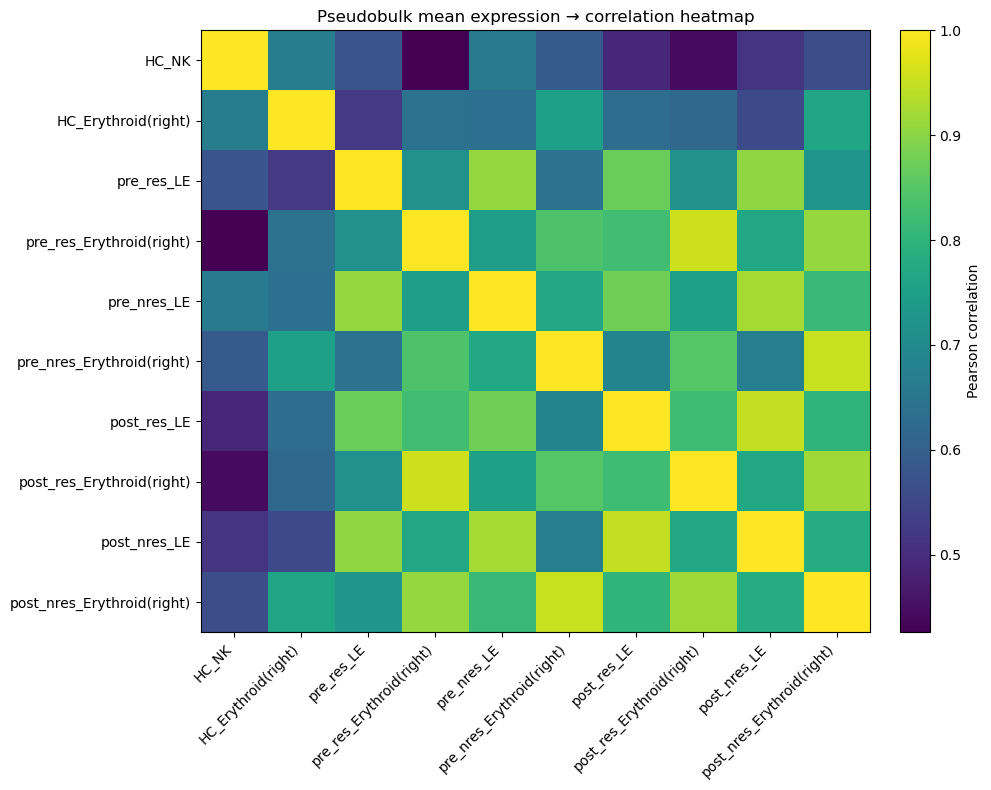

In [3]:

# ===== 3) 可选参数：你想用哪个表达来源 =====
USE_LAYER = None   # 例如 "lognorm" / "counts"；不用 layer 就 None
USE_RAW   = False  # 如果 True：用 adata.raw.X（且基因来自 adata.raw.var_names）

# ===== 4) 工具函数：取表达矩阵并确保是 dense =====
def get_X(adata, use_layer=None, use_raw=False):
    if use_raw:
        if adata.raw is None:
            raise ValueError("USE_RAW=True 但 adata.raw 为空")
        X = adata.raw.X
    elif use_layer is not None:
        if use_layer not in adata.layers:
            raise ValueError(f"layer '{use_layer}' 不存在。可用 layers={list(adata.layers.keys())}")
        X = adata.layers[use_layer]
    else:
        X = adata.X

    # sparse -> dense
    if hasattr(X, "toarray"):
        X = X.toarray()
    return X

def get_genes(adata, use_raw=False):
    return adata.raw.var_names if (use_raw and adata.raw is not None) else adata.var_names

# ===== 5) 取共同基因交集（非常关键）=====
gene_sets = [set(get_genes(ad, USE_RAW)) for ad in adatas.values()]
common_genes = sorted(set.intersection(*gene_sets))
if len(common_genes) == 0:
    raise ValueError("共同基因为 0：请检查是否有一个对象基因命名空间不同（例如 Ensembl vs Symbol）")

print(f"Common genes: {len(common_genes)}")

# ===== 6) 对齐到共同基因顺序，并做 pseudobulk（mean expression per group）=====
pb = {}  # group -> 1D vector (len common_genes)

for g, ad in adatas.items():
    genes = get_genes(ad, USE_RAW)
    # 建立 gene->index 映射，用于对齐
    idx_map = pd.Index(genes).get_indexer(common_genes)
    if (idx_map < 0).any():
        # 理论上不该发生（因为已取交集），但保底
        raise RuntimeError(f"{g} 对齐基因时出现缺失，请检查 var_names/raw.var_names")

    X = get_X(ad, USE_LAYER, USE_RAW)   # cells x genes(原顺序)
    Xc = X[:, idx_map]                  # cells x common_genes(对齐后)
    pb[g] = Xc.mean(axis=0)             # pseudobulk: mean over cells

# 组装成矩阵：genes x groups（便于相关性）
pb_mat = pd.DataFrame(pb, index=common_genes)  # rows=genes, cols=groups

# （可选）如果你担心不同组测序深度/尺度差异，可以做按基因 z-score，再相关
# pb_mat = pb_mat.apply(lambda col: (col - col.mean()) / (col.std(ddof=0) + 1e-8), axis=0)

# ===== 7) 相关性矩阵（group-by-group）=====
corr = pb_mat.corr(method="pearson")  # 也可以 "spearman"
print(corr.round(3))

# ===== 8) Heatmap（matplotlib）=====
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto", interpolation="nearest")
ax.set_xticks(range(corr.shape[1]))
ax.set_yticks(range(corr.shape[0]))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation", rotation=90)

ax.set_title("Pseudobulk mean expression → correlation heatmap")
plt.tight_layout()
plt.show()

# （可选）保存
fig.savefig("pseudobulk_correlation_heatmap.png", dpi=300, bbox_inches="tight")


In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import pdist, squareform

In [17]:


# --- PERMANOVA from scikit-bio ---
try:
    from skbio.stats.distance import permanova, DistanceMatrix
except ImportError as e:
    raise ImportError(
        "需要安装 scikit-bio 才能跑 permanova：\n"
        "pip install scikit-bio\n"
        "如果在服务器/conda：conda install -c conda-forge scikit-bio"
    )

# =========================
# 0) 你的对象：LE_AMLs / LE_norms 已经读入
# =========================
# LE_AMLs = {g: sc.read_h5ad(f) for g, f in LE_AML_files.items()}
# LE_norms = {g: sc.read_h5ad(f) for g, f in LE_norm_files.items()}

# =========================
# 1) 公共预处理：concat -> HVG -> PCA -> distance
# =========================
def build_distance_matrix(adatas_dict, group_names, label_key="group",
                          n_hvg=2000, n_pcs=30, metric="euclidean",
                          normalize=True, log1p=True, scale=True,
                          max_cells_per_group=None, random_state=0):
    """
    将多个 AnnData 合并（取共同基因），可选下采样，然后 PCA 后构建距离矩阵 DistanceMatrix。
    返回：dm, labels(Series), adata_merged
    """
    ad_list = []
    for g in group_names:
        ad = adatas_dict[g].copy()
        ad.obs[label_key] = g
        # 可选：每组下采样，避免某组细胞数过大主导距离结构
        if max_cells_per_group is not None and ad.n_obs > max_cells_per_group:
            rng = np.random.default_rng(random_state)
            keep = rng.choice(ad.n_obs, size=max_cells_per_group, replace=False)
            ad = ad[keep].copy()
        ad_list.append(ad)

    # join="inner" 自动取共同基因交集；label_key 作为 obs 列保留
    adata = sc.concat(ad_list, join="inner", label=None, index_unique="|")
    # 基本 QC：如果基因交集太少，permanova 没意义
    if adata.n_vars < 200:
        raise ValueError(f"共同基因太少（n_vars={adata.n_vars}），请检查 gene naming 是否一致（Symbol vs Ensembl）")

    # 统一预处理（建议对每次比较都做一次，避免不同对象预处理不一致）
    if normalize:
        sc.pp.normalize_total(adata, target_sum=1e4)
    if log1p:
        sc.pp.log1p(adata)

    # HVG：跨组比较时建议用 batch_key 指定组，减少“只对某一组高变”的偏差
    sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg, batch_key=label_key)
    adata = adata[:, adata.var["highly_variable"]].copy()

    if scale:
        sc.pp.scale(adata, max_value=10)

    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")
    X = adata.obsm["X_pca"]

    dist = squareform(pdist(X, metric=metric))
    dm = DistanceMatrix(dist, ids=adata.obs_names)
    labels = adata.obs[label_key].astype(str)

    return dm, labels, adata
def run_permanova(dm, labels, permutations=999):
    """
    兼容 scikit-bio permanova 在不同版本下返回：
    - PermanovaResults（属性访问）
    - pandas.Series / dict（键访问）
    """
    res = permanova(dm, labels, permutations=permutations)

    # ---- 统一取值函数：先尝试属性，再尝试键 ----
    def get_val(obj, keys, default=np.nan):
        # keys: list of candidate field names
        for k in keys:
            # attribute access
            if hasattr(obj, k):
                try:
                    v = getattr(obj, k)
                    if v is not None:
                        return v
                except Exception:
                    pass
            # key access (Series/dict)
            try:
                if isinstance(obj, (dict, pd.Series)) and k in obj:
                    return obj[k]
            except Exception:
                pass
        return default

    pseudo_F = get_val(res, ["test_statistic", "pseudo-F", "pseudo_F", "F"], default=np.nan)
    p_value  = get_val(res, ["p_value", "p-value", "p", "Pr(>F)"], default=np.nan)
    n        = get_val(res, ["sample_size", "n", "N"], default=np.nan)
    k_groups = get_val(res, ["number_of_groups", "k", "groups"], default=np.nan)
    perms    = get_val(res, ["permutations"], default=permutations)

    # ---- 计算一个近似 R2（解释度）----
    R2 = np.nan
    try:
        D = dm.data
        n_dm = D.shape[0]
        ss_total = (D**2).sum() / n_dm

        ss_within = 0.0
        for g, idx in labels.groupby(labels).groups.items():
            idx = list(idx)
            Dg = D[np.ix_(idx, idx)]
            ng = len(idx)
            ss_within += (Dg**2).sum() / ng

        ss_between = ss_total - ss_within
        R2 = ss_between / ss_total if ss_total > 0 else np.nan
    except Exception:
        pass

    out = {
        "pseudo_F": float(pseudo_F) if pseudo_F == pseudo_F else np.nan,
        "p_value": float(p_value) if p_value == p_value else np.nan,
        "n": int(n) if n == n else np.nan,
        "k_groups": int(k_groups) if k_groups == k_groups else np.nan,
        "R2": float(R2) if R2 == R2 else np.nan,
        "permutations": int(perms) if perms == perms else permutations,
    }
    return out


def pairwise_permanova(adatas_dict, group_names, permutations=999, **kwargs):
    """
    对 group_names 做两两 permanova（每次只比较两组）
    """
    rows = []
    for i in range(len(group_names)):
        for j in range(i+1, len(group_names)):
            g1, g2 = group_names[i], group_names[j]
            dm, labels, _ = build_distance_matrix(adatas_dict, [g1, g2], **kwargs)
            r = run_permanova(dm, labels, permutations=permutations)
            r.update({"group1": g1, "group2": g2})
            rows.append(r)
    return pd.DataFrame(rows).sort_values(["p_value", "pseudo_F"], ascending=[True, False])

def overall_permanova(adatas_dict, group_names, permutations=999, **kwargs):
    """
    对 group_names 作为多组一次性 permanova（检验“是否存在组间差异”）
    """
    dm, labels, _ = build_distance_matrix(adatas_dict, group_names, **kwargs)
    r = run_permanova(dm, labels, permutations=permutations)
    r.update({"groups": " | ".join(group_names)})
    return pd.DataFrame([r])

# =========================
# 2) 你要的三类检验
# =========================

# 建议：为了公平，给每组最多抽样同样数量细胞（可按你数据规模改）
COMMON_KW = dict(
    n_hvg=2000,
    n_pcs=30,
    metric="euclidean",
    max_cells_per_group=3000,   # 你可改成 None（不抽样）或 1000/2000/5000
    random_state=0
)

PERMUTATIONS = 999

# --- (1) LE_AMLs 内部：是否同一种（整体+两两） ---
LE_AML_groups = list(LE_AMLs.keys())
LE_AML_overall = overall_permanova(LE_AMLs, LE_AML_groups, permutations=PERMUTATIONS, **COMMON_KW)
LE_AML_pairwise = pairwise_permanova(LE_AMLs, LE_AML_groups, permutations=PERMUTATIONS, **COMMON_KW)

# --- (2) LE_norms 内部：是否同一种（整体+两两） ---
LE_norm_groups = list(LE_norms.keys())
LE_norm_overall = overall_permanova(LE_norms, LE_norm_groups, permutations=PERMUTATIONS, **COMMON_KW)
LE_norm_pairwise = pairwise_permanova(LE_norms, LE_norm_groups, permutations=PERMUTATIONS, **COMMON_KW)

# --- (3) 同一 cohort 内：LE vs Erythroid(right) 是否同一种 ---
# 你这里的“同一 cohort”对应 pre_res / pre_nres / post_res / post_nres（以及 HC）
# 我们用前缀匹配：prefix = "pre_res", 在两个 dict 里分别找 prefix+"_LE" 和 prefix+"_Erythroid(right)"
def extract_prefix(name):
    # e.g. "pre_res_LE" -> "pre_res"
    # e.g. "pre_res_Erythroid(right)" -> "pre_res"
    if name.endswith("_LE"):
        return name[:-3]
    if name.endswith("_Erythroid(right)"):
        return name[:-len("_Erythroid(right)")]
    return None

aml_prefixes = set(filter(None, [extract_prefix(k) for k in LE_AMLs.keys()]))
norm_prefixes = set(filter(None, [extract_prefix(k) for k in LE_norms.keys()]))
common_prefixes = sorted(list(aml_prefixes.intersection(norm_prefixes)))

rows = []
for pref in common_prefixes:
    g_aml = f"{pref}_LE"
    g_norm = f"{pref}_Erythroid(right)"
    dm, labels, _ = build_distance_matrix(
        # 这里把两边临时合到一个 dict 里
        {g_aml: LE_AMLs[g_aml], g_norm: LE_norms[g_norm]},
        [g_aml, g_norm],
        **COMMON_KW
    )
    r = run_permanova(dm, labels, permutations=PERMUTATIONS)
    r.update({"cohort": pref, "group1": g_aml, "group2": g_norm})
    rows.append(r)

LE_vs_Ery_pairwise = pd.DataFrame(rows).sort_values(["p_value", "pseudo_F"], ascending=[True, False])

# =========================
# 3) 输出结果
# =========================
print("\n=== (1) LE_AMLs overall PERMANOVA ===")
print(LE_AML_overall.to_string(index=False))

print("\n=== (1) LE_AMLs pairwise PERMANOVA (top 20 by p) ===")
print(LE_AML_pairwise.head(20).to_string(index=False))

print("\n=== (2) LE_norms overall PERMANOVA ===")
print(LE_norm_overall.to_string(index=False))

print("\n=== (2) LE_norms pairwise PERMANOVA (top 20 by p) ===")
print(LE_norm_pairwise.head(20).to_string(index=False))

print("\n=== (3) Within-cohort: LE vs Erythroid(right) ===")
print(LE_vs_Ery_pairwise.to_string(index=False))

# （可选）保存
LE_AML_overall.to_csv("permanova_LE_AMLs_overall.csv", index=False)
LE_AML_pairwise.to_csv("permanova_LE_AMLs_pairwise.csv", index=False)
LE_norm_overall.to_csv("permanova_LE_norms_overall.csv", index=False)
LE_norm_pairwise.to_csv("permanova_LE_norms_pairwise.csv", index=False)
LE_vs_Ery_pairwise.to_csv("permanova_within_cohort_LE_vs_Ery.csv", index=False)


d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.



=== (1) LE_AMLs overall PERMANOVA ===
 pseudo_F  p_value   n  k_groups  R2  permutations                                                        groups
      NaN    0.001 NaN       NaN NaN           999 HC_NK | pre_res_LE | pre_nres_LE | post_res_LE | post_nres_LE

=== (1) LE_AMLs pairwise PERMANOVA (top 20 by p) ===
 pseudo_F  p_value   n  k_groups  R2  permutations      group1       group2
      NaN    0.001 NaN       NaN NaN           999       HC_NK   pre_res_LE
      NaN    0.001 NaN       NaN NaN           999       HC_NK  pre_nres_LE
      NaN    0.001 NaN       NaN NaN           999       HC_NK  post_res_LE
      NaN    0.001 NaN       NaN NaN           999       HC_NK post_nres_LE
      NaN    0.001 NaN       NaN NaN           999  pre_res_LE  pre_nres_LE
      NaN    0.001 NaN       NaN NaN           999  pre_res_LE  post_res_LE
      NaN    0.001 NaN       NaN NaN           999  pre_res_LE post_nres_LE
      NaN    0.001 NaN       NaN NaN           999 pre_nres_LE  post_res_

d:\Gaol\miniconda3\envs\geneformer_env\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
d:\Gaol\miniconda3\envs\geneformer_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [18]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import PCA


In [19]:
def compute_pseudobulk(adatas_dict, use_log=True):
    """
    输入：{group_name: AnnData}
    输出：DataFrame (groups x genes)
    """
    # 共同基因交集
    gene_sets = [set(ad.var_names) for ad in adatas_dict.values()]
    common_genes = sorted(set.intersection(*gene_sets))

    rows = []
    for g, ad in adatas_dict.items():
        X = ad[:, common_genes].X
        if hasattr(X, "toarray"):
            X = X.toarray()
        if use_log:
            X = np.log1p(X)
        rows.append(X.mean(axis=0))

    pb = pd.DataFrame(rows, index=adatas_dict.keys(), columns=common_genes)
    return pb


In [20]:
pb_LE_AML  = compute_pseudobulk(LE_AMLs)
pb_Ery    = compute_pseudobulk(LE_norms)


In [21]:
def pca_on_pseudobulk(pb, n_components=3):
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(pb.values)
    Z = pd.DataFrame(Z, index=pb.index,
                     columns=[f"PC{i+1}" for i in range(Z.shape[1])])
    return Z, pca


In [22]:
Z_LE,  pca_LE  = pca_on_pseudobulk(pb_LE_AML, n_components=3)
Z_Ery, pca_Ery = pca_on_pseudobulk(pb_Ery,    n_components=3)


In [23]:
from statsmodels.multivariate.manova import MANOVA

df = Z_LE.copy()
df["group"] = df.index

maov = MANOVA.from_formula("PC1 + PC2 + PC3 ~ group", data=df)
print(maov.mv_test())


                        Multivariate linear model
                                                                          
--------------------------------------------------------------------------
       Intercept                Value         Num DF Den DF F Value Pr > F
--------------------------------------------------------------------------
          Wilks' lambda                0.0000 1.0000 0.0000  0.0000    nan
         Pillai's trace                1.0203 1.0000 0.0000 -0.0000    nan
 Hotelling-Lawley trace 9007199254740991.0000 1.0000 0.0000  0.0000    nan
    Roy's greatest root 9007199254740991.0000 1.0000 0.0000  0.0000    nan
--------------------------------------------------------------------------
                                                                          
----------------------------------------------------------------------------
             group            Value     Num DF    Den DF    F Value   Pr > F
----------------------------------------------

d:\Gaol\miniconda3\envs\geneformer_env\lib\site-packages\statsmodels\multivariate\multivariate_ols.py:166: RuntimeWarning: divide by zero encountered in scalar divide
  eigv1 = np.array([i / (1 - i) for i in eigv2])
d:\Gaol\miniconda3\envs\geneformer_env\lib\site-packages\statsmodels\multivariate\multivariate_ols.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  F = (1 - lmd) / lmd * df2 / df1
d:\Gaol\miniconda3\envs\geneformer_env\lib\site-packages\statsmodels\multivariate\multivariate_ols.py:235: RuntimeWarning: invalid value encountered in scalar multiply
  F = df2 / df1 * sigma


In [24]:
df = Z_Ery.copy()
df["group"] = df.index

maov = MANOVA.from_formula("PC1 + PC2 + PC3 ~ group", data=df)
print(maov.mv_test())


                                 Multivariate linear model
                                                                                            
-----------------------------------------------------------------------------------------------
              Intercept                  Value            Num DF    Den DF    F Value    Pr > F
-----------------------------------------------------------------------------------------------
                 Wilks' lambda                  0.0000    1.0000    0.0000     0.0000       nan
                Pillai's trace                  1.0008    1.0000    0.0000    -0.0000       nan
        Hotelling-Lawley trace    900719925474098.2500    1.0000    0.0000     0.0000       nan
           Roy's greatest root    900719925474098.2500    1.0000    0.0000     0.0000       nan
--------------------------------------------------------------------------------------------
                                                                                   

d:\Gaol\miniconda3\envs\geneformer_env\lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)


In [25]:
from scipy.stats import f

def hotelling_t2(X, Y):
    n1, n2 = X.shape[0], Y.shape[0]
    p = X.shape[1]

    mean_diff = X.mean(axis=0) - Y.mean(axis=0)
    S1 = np.cov(X, rowvar=False)
    S2 = np.cov(Y, rowvar=False)
    Sp = ((n1 - 1)*S1 + (n2 - 1)*S2) / (n1 + n2 - 2)

    T2 = (n1*n2)/(n1+n2) * mean_diff @ np.linalg.pinv(Sp) @ mean_diff

    F = (n1 + n2 - p - 1) * T2 / ((n1 + n2 - 2) * p)
    pval = 1 - f.cdf(F, p, n1 + n2 - p - 1)

    return T2, F, pval


In [29]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist

# ---------- Energy statistic ----------
def energy_statistic(X, Y):
    """
    E = 2*mean(||X-Y||) - mean(||X-X'||) - mean(||Y-Y'||)
    越大表示分布越不同；接近 0 表示分布非常接近
    """
    d_xy = cdist(X, Y, metric="euclidean").mean()
    d_xx = cdist(X, X, metric="euclidean").mean()
    d_yy = cdist(Y, Y, metric="euclidean").mean()
    return 2*d_xy - d_xx - d_yy

def energy_test_permutation(X, Y, permutations=999, random_state=0):
    rng = np.random.default_rng(random_state)
    n, m = X.shape[0], Y.shape[0]
    Z = np.vstack([X, Y])
    obs = energy_statistic(X, Y)

    cnt = 0
    for _ in range(permutations):
        perm = rng.permutation(n + m)
        Xp = Z[perm[:n]]
        Yp = Z[perm[n:]]
        stat = energy_statistic(Xp, Yp)
        if stat >= obs:
            cnt += 1

    # +1 平滑，避免 p=0
    p = (cnt + 1) / (permutations + 1)
    return obs, p


In [30]:
def compare_two_adatas_on_harmony(
    ad1, ad2,
    name1="group1", name2="group2",
    emb_key="X_harmony",
    max_cells_each=1500,
    permutations=999,
    random_state=0,
    alpha=0.05
):
    if emb_key not in ad1.obsm:
        raise KeyError(f"{name1} 缺少 ad1.obsm['{emb_key}']，可用 keys={list(ad1.obsm_keys())}")
    if emb_key not in ad2.obsm:
        raise KeyError(f"{name2} 缺少 ad2.obsm['{emb_key}']，可用 keys={list(ad2.obsm_keys())}")

    X = ad1.obsm[emb_key]
    Y = ad2.obsm[emb_key]
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    Y = Y.toarray() if hasattr(Y, "toarray") else np.asarray(Y)

    if X.shape[0] < 20 or Y.shape[0] < 20:
        raise ValueError(f"细胞数太少：{name1}={X.shape[0]}, {name2}={Y.shape[0]}（建议每组>=20）")

    rng = np.random.default_rng(random_state)
    if max_cells_each is not None:
        if X.shape[0] > max_cells_each:
            X = X[rng.choice(X.shape[0], size=max_cells_each, replace=False)]
        if Y.shape[0] > max_cells_each:
            Y = Y[rng.choice(Y.shape[0], size=max_cells_each, replace=False)]

    effect, p = energy_test_permutation(X, Y, permutations=permutations, random_state=random_state)
    decision = "different" if p < alpha else "indistinguishable"

    return {
        "group1": name1,
        "group2": name2,
        "n1": int(X.shape[0]),
        "n2": int(Y.shape[0]),
        "effect_energy": float(effect),  # 越大越不同
        "p_value": float(p),
        "decision": decision,
        "permutations": int(permutations),
        "emb_key": emb_key
    }


In [32]:
def pairwise_energy_tests(adatas_dict, emb_key="X_harmony",
                          max_cells_each=1500, permutations=999, random_state=0, alpha=0.05):
    names = list(adatas_dict.keys())
    rows = []
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            g1, g2 = names[i], names[j]
            rows.append(compare_two_adatas_on_harmony(
                adatas_dict[g1], adatas_dict[g2],
                name1=g1, name2=g2,
                emb_key=emb_key,
                max_cells_each=max_cells_each,
                permutations=permutations,
                random_state=random_state,
                alpha=alpha
            ))
    df = pd.DataFrame(rows).sort_values(["p_value", "effect_energy"], ascending=[True, False])
    return df
def overall_call_from_pairwise(df_pairwise, alpha=0.05):
    if df_pairwise.empty:
        return {"overall": "NA", "reason": "no comparisons"}
    n_sig = int((df_pairwise["p_value"] < alpha).sum())
    overall = "likely same" if n_sig == 0 else "heterogeneous"
    return {
        "overall": overall,
        "n_pairwise": int(df_pairwise.shape[0]),
        "n_significant": n_sig,
        "alpha": float(alpha),
    }


In [33]:
# ===== 参数 =====
EMB_KEY = "X_harmony"     # 若你的 key 不叫这个，在这里改
PERMUTATIONS = 999
MAX_CELLS_EACH = 1500
ALPHA = 0.05
RANDOM_STATE = 0

# 1) LE_AML_files 是否同一种细胞：两两检验 + overall
df_LE_AML_pairwise = pairwise_energy_tests(
    LE_AMLs,
    emb_key=EMB_KEY,
    max_cells_each=MAX_CELLS_EACH,
    permutations=PERMUTATIONS,
    random_state=RANDOM_STATE,
    alpha=ALPHA
)
overall_LE_AML = overall_call_from_pairwise(df_LE_AML_pairwise, alpha=ALPHA)

print("=== 1) LE_AMLs overall ===")
print(overall_LE_AML)
print(df_LE_AML_pairwise.head(20))

# 2) LE_norms 是否同一种细胞：两两检验 + overall
df_LE_norm_pairwise = pairwise_energy_tests(
    LE_norms,
    emb_key=EMB_KEY,
    max_cells_each=MAX_CELLS_EACH,
    permutations=PERMUTATIONS,
    random_state=RANDOM_STATE,
    alpha=ALPHA
)
overall_LE_norm = overall_call_from_pairwise(df_LE_norm_pairwise, alpha=ALPHA)

print("\n=== 2) LE_norms overall ===")
print(overall_LE_norm)
print(df_LE_norm_pairwise.head(20))

# 3) 同一 cohort：LE vs Erythroid(right) 是否同一种细胞
def cohort_prefix_from_name(name):
    # "pre_res_LE" -> "pre_res"
    # "pre_res_Erythroid(right)" -> "pre_res"
    if name.endswith("_LE"):
        return name[:-3]
    if name.endswith("_Erythroid(right)"):
        return name[:-len("_Erythroid(right)")]
    return None

aml_prefixes = {cohort_prefix_from_name(k) for k in LE_AMLs.keys()}
norm_prefixes = {cohort_prefix_from_name(k) for k in LE_norms.keys()}
common_prefixes = sorted([p for p in aml_prefixes.intersection(norm_prefixes) if p])

rows = []
for pref in common_prefixes:
    g_aml = f"{pref}_LE"
    g_norm = f"{pref}_Erythroid(right)"
    r = compare_two_adatas_on_harmony(
        LE_AMLs[g_aml], LE_norms[g_norm],
        name1=g_aml, name2=g_norm,
        emb_key=EMB_KEY,
        max_cells_each=MAX_CELLS_EACH,
        permutations=PERMUTATIONS,
        random_state=RANDOM_STATE,
        alpha=ALPHA
    )
    r["cohort"] = pref
    rows.append(r)

df_within_cohort = pd.DataFrame(rows).sort_values(["p_value", "effect_energy"], ascending=[True, False])

print("\n=== 3) within cohort: LE vs Erythroid(right) ===")
print(df_within_cohort)

# （可选）保存
# df_LE_AML_pairwise.to_csv("energy_LE_AMLs_pairwise_on_harmony.csv", index=False)
# df_LE_norm_pairwise.to_csv("energy_LE_norms_pairwise_on_harmony.csv", index=False)
# df_within_cohort.to_csv("energy_within_cohort_LE_vs_Ery_on_harmony.csv", index=False)


=== 1) LE_AMLs overall ===
{'overall': 'heterogeneous', 'n_pairwise': 10, 'n_significant': 10, 'alpha': 0.05}
        group1        group2   n1   n2  effect_energy  p_value   decision  \
2        HC_NK   post_res_LE   78  136       9.377087    0.001  different   
3        HC_NK  post_nres_LE   78  196       7.633866    0.001  different   
0        HC_NK    pre_res_LE   78  126       6.211537    0.001  different   
1        HC_NK   pre_nres_LE   78  167       3.235419    0.001  different   
7  pre_nres_LE   post_res_LE  167  136       2.468009    0.001  different   
8  pre_nres_LE  post_nres_LE  167  196       1.532264    0.001  different   
4   pre_res_LE   pre_nres_LE  126  167       1.169669    0.001  different   
5   pre_res_LE   post_res_LE  126  136       1.130973    0.001  different   
9  post_res_LE  post_nres_LE  136  196       0.634481    0.001  different   
6   pre_res_LE  post_nres_LE  126  196       0.600894    0.003  different   

   permutations    emb_key  
2           9

In [34]:

df_LE_AML_pairwise.to_csv("energy_LE_AMLs_pairwise_on_harmony.csv", index=False)
df_LE_norm_pairwise.to_csv("energy_LE_norms_pairwise_on_harmony.csv", index=False)
df_within_cohort.to_csv("energy_within_cohort_LE_vs_Ery_on_harmony.csv", index=False)